# Assignment 6: Tree-Based Methods

## Introduction
In this coursework, you will classify houses into **high price** and **low price** categories based on their characteristics using tree-based methods.

### **Objectives**
- Use the **Ames Housing dataset**, which contains detailed property attributes.
- Train and compare **Decision Tree, Random Forest, and XGBoost** classifiers.
- Evaluate models using **confusion matrices and ROC-AUC**.
- Optimize hyperparameters with **GridSearchCV**.
- Interpret model decisions using **SHAP explainability**.

In [1]:
# Basic imports
import numpy as np
import pandas as pd
import polars as pl

# Scikit-learn
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# SHAP for explainability
import shap
shap.initjs()

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### **Dataset Description**
The dataset used is the **Ames Housing dataset**, which contains detailed information about residential houses in Ames, Iowa. Each row represents a house, and each column describes a characteristic of that house. Let's understand the **15 most important features** in the dataset:

1. **OverallQual**: The overall material and finish quality of the house.
2. **GrLivArea**: Above ground living area in square feet.
3. **GarageCars**: Number of car spaces in the garage.
4. **TotalBsmtSF**: Total basement area in square feet.
5. **1stFlrSF**: First-floor area in square feet.
6. **FullBath**: Number of full bathrooms.
7. **TotRmsAbvGrd**: Total number of rooms above ground level (excluding bathrooms).
8. **YearBuilt**: Year the house was constructed.
9. **Fireplaces**: Number of fireplaces in the house.
10. **GarageArea**: Size of the garage in square feet.
11. **LotArea**: Total lot size in square feet.
12. **KitchenQual**: Kitchen quality rating.
13. **BsmtFinSF1**: Finished basement square footage.
14. **Neighborhood**: The general location of the property within Ames.
15. **MSSubClass**: Identifies the type of dwelling.


- **Target Variable:** `SalePrice` (converted into a classification task: High vs. Low price).

## **Question 1: Data Preprocessing**
Before training your models, you need to clean and preprocess the dataset.

1. **Load the data `housing.csv` and display the first 5 rows.**

In [4]:
#Load the housing data
# Load Ames Housing Dataset
df=pl.read_csv('housing.csv')


# Display the first few rows
df.head()

Unnamed: 0,Order,PID,MS SubClass,MS Zoning,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Exter Qual,Exter Cond,Foundation,Heating,Heating QC,Central Air,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
i64,i64,i64,i64,str,i64,str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,str,i64,str,i64,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,str,i64
0,1,526301100,20,"""RL""",31770,"""Pave""","""IR1""","""Lvl""","""AllPub""","""Corner""","""Gtl""","""NAmes""","""Norm""","""Norm""","""1Fam""","""1Story""",6,5,1960,1960,"""Hip""","""CompShg""","""BrkFace""","""Plywood""","""TA""","""TA""","""CBlock""","""GasA""","""Fa""","""Y""",1656,0,0,1656,1,0,3,1,"""TA""",7,"""Typ""",2,"""P""",210,62,0,0,0,0,0,5,2010,"""WD ""","""Normal""",215000
1,2,526350040,20,"""RH""",11622,"""Pave""","""Reg""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""NAmes""","""Feedr""","""Norm""","""1Fam""","""1Story""",5,6,1961,1961,"""Gable""","""CompShg""","""VinylSd""","""VinylSd""","""TA""","""TA""","""CBlock""","""GasA""","""TA""","""Y""",896,0,0,896,1,0,2,1,"""TA""",5,"""Typ""",0,"""Y""",140,0,0,0,120,0,0,6,2010,"""WD ""","""Normal""",105000
2,3,526351010,20,"""RL""",14267,"""Pave""","""IR1""","""Lvl""","""AllPub""","""Corner""","""Gtl""","""NAmes""","""Norm""","""Norm""","""1Fam""","""1Story""",6,6,1958,1958,"""Hip""","""CompShg""","""Wd Sdng""","""Wd Sdng""","""TA""","""TA""","""CBlock""","""GasA""","""TA""","""Y""",1329,0,0,1329,1,1,3,1,"""Gd""",6,"""Typ""",0,"""Y""",393,36,0,0,0,0,12500,6,2010,"""WD ""","""Normal""",172000
3,4,526353030,20,"""RL""",11160,"""Pave""","""Reg""","""Lvl""","""AllPub""","""Corner""","""Gtl""","""NAmes""","""Norm""","""Norm""","""1Fam""","""1Story""",7,5,1968,1968,"""Hip""","""CompShg""","""BrkFace""","""BrkFace""","""Gd""","""TA""","""CBlock""","""GasA""","""Ex""","""Y""",2110,0,0,2110,2,1,3,1,"""Ex""",8,"""Typ""",2,"""Y""",0,0,0,0,0,0,0,4,2010,"""WD ""","""Normal""",244000
4,5,527105010,60,"""RL""",13830,"""Pave""","""IR1""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""Gilbert""","""Norm""","""Norm""","""1Fam""","""2Story""",5,5,1997,1998,"""Gable""","""CompShg""","""VinylSd""","""VinylSd""","""TA""","""TA""","""PConc""","""GasA""","""Gd""","""Y""",928,701,0,1629,2,1,3,1,"""TA""",6,"""Typ""",1,"""Y""",212,34,0,0,0,0,0,3,2010,"""WD ""","""Normal""",189900


1. **Convert the `SalePrice` column into a binary classification variable:**
   - If the house price is **above the median**, label it as **1 (High price)**.
   - If the house price is **below the median**, label it as **0 (Low price)**.
   
2. **Drop the original `SalePrice` column** after conversion.

3. **Encode categorical variables**:
   - Some columns contain text (e.g., `Neighborhood`, `House Style`).
   - Convert them into numerical values using **Label Encoding**.

4. **Standardize numerical features**:
   - Scale numerical values to improve model performance.
   - Use `StandardScaler()` from `sklearn.preprocessing`.

5. **Split the dataset into training and testing sets**:
   - Use an **80-20 split** (`train_test_split`).
   - Set `random_state=42` for reproducibility.
   - Use `stratify=y` to maintain class balance.

In [5]:
# Convert SalePrice into a binary target variable (1 for high price, 0 for low price)
mprice=df['SalePrice'].median()
df = df.with_columns(pl.when(pl.col("SalePrice") > mprice).then(1).otherwise(0).alias("price_category"))

In [6]:
# Drop original SalePrice column
df=df.drop('SalePrice')

In [21]:
# Encode categorical variables
categorical_columns = [col for col in df.columns if df[col].dtype == pl.Utf8]
label_encoder = LabelEncoder()
df = df.with_columns([pl.Series(col, label_encoder.fit_transform(df[col].to_list())).alias(col)for col in categorical_columns])

In [27]:
# Define Features (X) and Target (y)
x=df.drop('price_category','Unnamed: 0','Order','PID')
y=df['price_category']

In [28]:
# Convert X to NumPy before train-test split
x = x.to_numpy()
y = y.to_numpy()

In [29]:
# Perform Train-Test Split (with stratification)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [30]:
# Standardize Numerical Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **Question 2: Model Training and Evaluation**
You will train two classification models:
- **Decision Tree** (`random_state = 42`)
- **Random Forest** (`random_state = 42`)

1. **Train the models on the training set. Make sure you use the optimal number of trees for the Random Forest.**.
2. **Evaluate models using the following metrics**:
   - **Confusion Matrix**: Displays True Positives, True Negatives, False Positives, and False Negatives.
   - **ROC-AUC Score**: Measures the model’s ability to distinguish between classes.
   - **ROC Curve**: Plots True Positive Rate (TPR) vs. False Positive Rate (FPR).

3. **Plot the ROC curves for all models in one figure**.

In [34]:
# Define hyperparameter grids
rf_param_grid = {'n_estimators': [50, 100, 150, 200, 300],
                 'max_depth': [None, 10, 20, 30],
                 'min_samples_split': [2, 5, 10]}


In [35]:
# Define base models
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)

In [33]:
# Store optimized models


In [ ]:
# Hyperparameter tuning and model evaluation


In [38]:
    # Apply Grid Search only for Random Forest
grid_search_rf = GridSearchCV(estimator=rf_model,
                              param_grid=rf_param_grid,
                              cv=5,
                              scoring='roc_auc',
                              n_jobs=-1)
grid_search_rf.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 150, 200, 300]},
             scoring='roc_auc')

In [41]:
    # Store the optimized model
best_rf_model = grid_search_rf.best_estimator_
print(f"Best Parameters: {grid_search_rf.best_params_}")

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}


In [42]:
    # Train the model
dt_model.fit(X_train_scaled, y_train)
best_rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=300,
                       random_state=42)

In [48]:
    # Predictions
dt_preds = dt_model.predict(X_test_scaled)
rf_preds = best_rf_model.predict(X_test_scaled)

In [51]:
    # Evaluation metrics
dt_conf_matrix = confusion_matrix(y_test, dt_preds)
rf_conf_matrix = confusion_matrix(y_test, rf_preds)
print(f"Decision Tree Confusion Matrix:\n{dt_conf_matrix}")
print(f"Random Forest Confusion Matrix:\n{rf_conf_matrix}")

Decision Tree Confusion Matrix:
[[242  51]
 [ 31 262]]
Random Forest Confusion Matrix:
[[276  17]
 [ 25 268]]


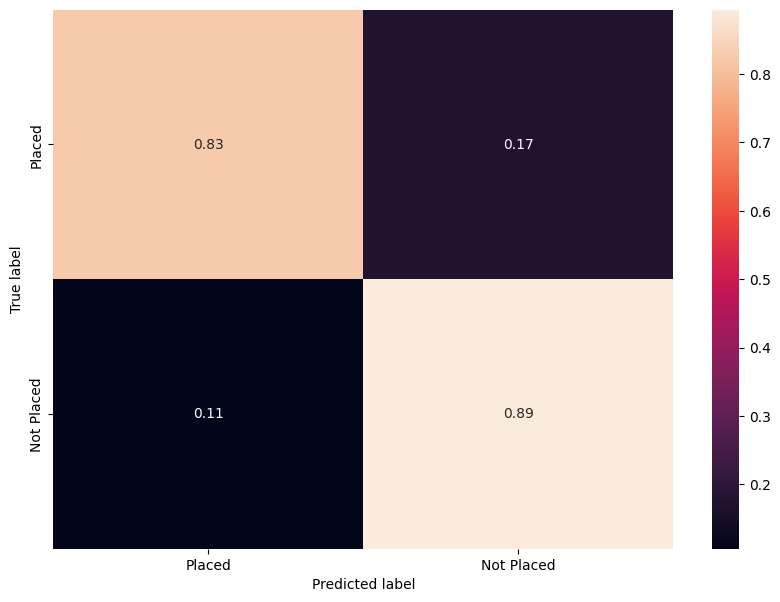

In [62]:
# Turn matrix to percentages
confusion_matrix_dt = dt_conf_matrix.astype('float') / dt_conf_matrix.sum(axis=1)[:, np.newaxis]

# Turn to dataframe
df_cm1 = pd.DataFrame(
        confusion_matrix_dt, index=['Placed', 'Not Placed'],
        columns=['Placed', 'Not Placed'],
)

# Parameters of the image
figsize = (10,7)
fontsize=14

# Create image
fig = plt.figure(figsize=figsize)
heatmap1 = sns.heatmap(df_cm1, annot=True, fmt='.2f')

# Make it nicer
heatmap.yaxis.set_ticklabels(heatmap1.yaxis.get_ticklabels(), rotation=0,
                             ha='right', fontsize=fontsize)
heatmap.xaxis.set_ticklabels(heatmap1.xaxis.get_ticklabels(), rotation=45,
                             ha='right', fontsize=fontsize)

# Add labels
plt.ylabel('True label')
plt.xlabel('Predicted label')

# Plot!
plt.show()

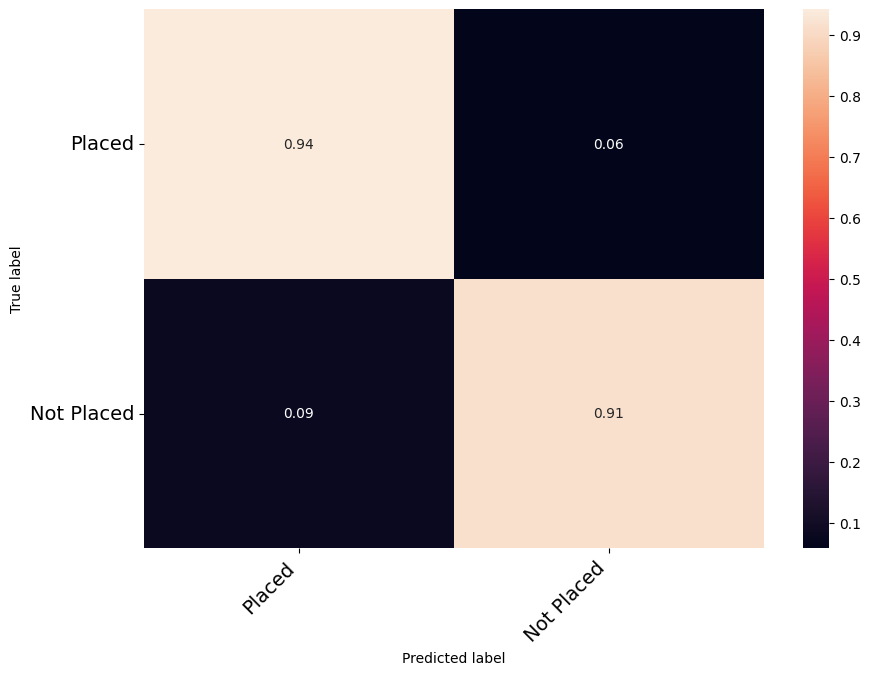

In [60]:
# Turn matrix to percentages
confusion_matrix_rf = rf_conf_matrix.astype('float') / rf_conf_matrix.sum(axis=1)[:, np.newaxis]

# Turn to dataframe
df_cm = pd.DataFrame(
        confusion_matrix_rf, index=['Placed', 'Not Placed'],
        columns=['Placed', 'Not Placed'],
)

# Parameters of the image
figsize = (10,7)
fontsize=14

# Create image
fig = plt.figure(figsize=figsize)
heatmap = sns.heatmap(df_cm, annot=True, fmt='.2f')

# Make it nicer
heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0,
                             ha='right', fontsize=fontsize)
heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45,
                             ha='right', fontsize=fontsize)

# Add labels
plt.ylabel('True label')
plt.xlabel('Predicted label')

# Plot!
plt.show()

In [63]:
    # ROC Curve
dt_roc_auc = roc_auc_score(y_test, dt_model.predict_proba(X_test_scaled)[:, 1])
rf_roc_auc = roc_auc_score(y_test, best_rf_model.predict_proba(X_test_scaled)[:, 1])
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_model.predict_proba(X_test_scaled)[:, 1])
rf_fpr, rf_tpr, _ = roc_curve(y_test, best_rf_model.predict_proba(X_test_scaled)[:, 1])
print(f"Decision Tree ROC-AUC: {dt_roc_auc:.2f}")
print(f"Random Forest ROC-AUC: {rf_roc_auc:.2f}")

Decision Tree ROC-AUC: 0.86
Random Forest ROC-AUC: 0.98


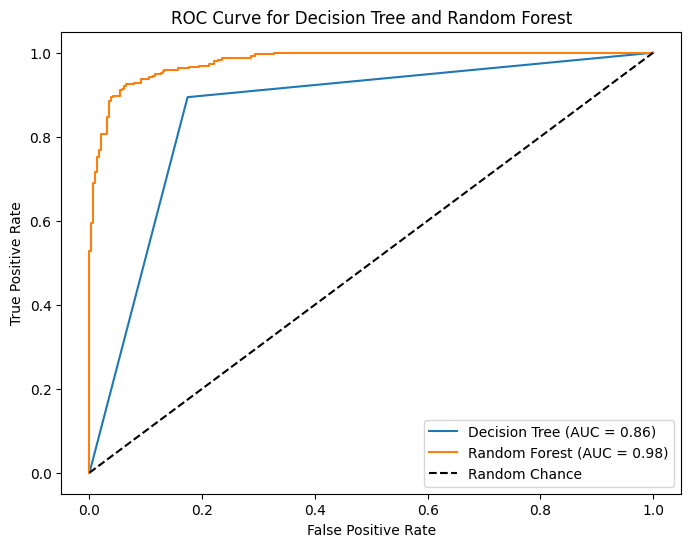

In [64]:
# Plot ROC Curves
plt.figure(figsize=(8, 6))
plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC = {dt_roc_auc:.2f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Decision Tree and Random Forest")
plt.legend()
plt.show()

## **Question 3: Hyperparameter Tuning**
Hyperparameter tuning helps improve model performance by finding the best parameters.

1. **Tune XGBoost using GridSearchCV with five folds**:
   - Search for the best `n_estimators`, `max_depth`, and `learning_rate`.

2. **Show the best number for each hyperparameter**:

3. **Calculate a ROC curve and its corresponding AUC. Compare these results with the previous models.**

In [65]:
# Define the hyperparameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2]}

In [66]:
# Initialize the XGBoost classifier
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

In [67]:
# Perform Grid Search with 5-fold cross-validation
grid_search_xgb = GridSearchCV(estimator=xgb_model,
                               param_grid=param_grid_xgb,
                               scoring='roc_auc',
                               cv=5,
                               n_jobs=-1)
grid_search_xgb.fit(X_train_scaled, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:31:23] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                         'max_depth': [3, 5, 7, 10],
                         'n_estimators': [50, 100, 150, 200]},
             scoring='roc_auc')

In [70]:
# Display the best hyperparameters
best_xgb_model = grid_search_xgb.best_estimator_
print("Best XGBoost parameters:", grid_search_xgb.best_params_)

Best XGBoost parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


In [71]:
# Get the best model
xgb_preds = best_xgb_model.predict(X_test_scaled)
xgb_probs = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

In [72]:
# Train with best hyperparameters
best_xgb_model.fit(X_train_scaled, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:33:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [78]:
# Predictions
xgb_preds = best_xgb_model.predict(X_test_scaled)
xgb_probs = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

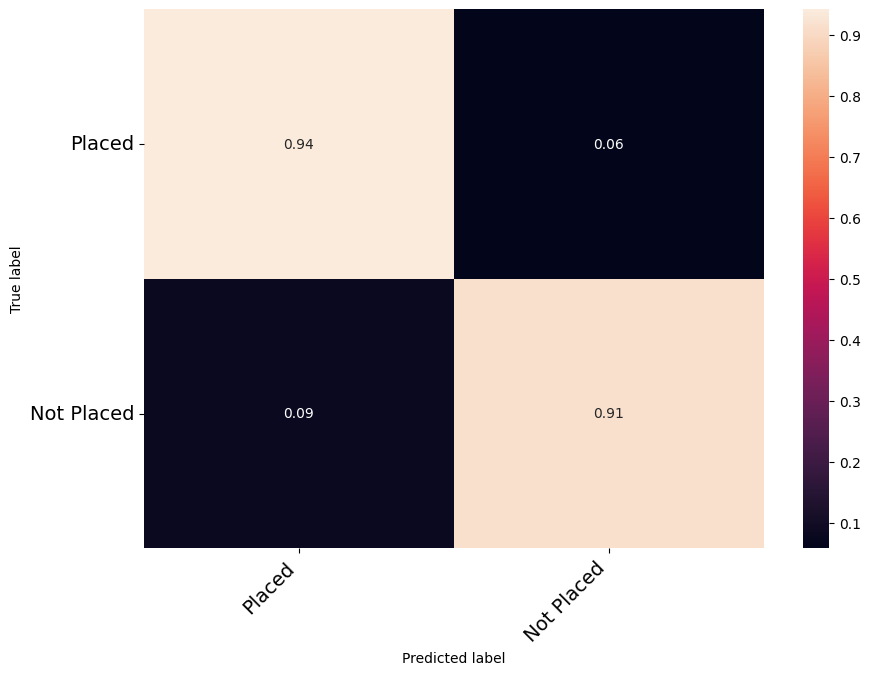

In [80]:
# Evaluation metrics for XGBoost
cm_xgb = confusion_matrix(y_test, xgb_preds)
roc_auc_xgb = roc_auc_score(y_test, xgb_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

# Turn matrix to percentages
confusion_matrix_xgb= cm_xgb.astype('float') / cm_xgb.sum(axis=1)[:, np.newaxis]

# Turn to dataframe
df_cm = pd.DataFrame(
        confusion_matrix_rf, index=['Placed', 'Not Placed'],
        columns=['Placed', 'Not Placed'],
)

# Parameters of the image
figsize = (10,7)
fontsize=14

# Create image
fig = plt.figure(figsize=figsize)
heatmap = sns.heatmap(df_cm, annot=True, fmt='.2f')

# Make it nicer
heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0,
                             ha='right', fontsize=fontsize)
heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45,
                             ha='right', fontsize=fontsize)

# Add labels
plt.ylabel('True label')
plt.xlabel('Predicted label')

# Plot!
plt.show()

In [81]:
print("XGBoost Confusion Matrix:")
print(cm_xgb)
print(f"XGBoost ROC-AUC Score: {roc_auc_xgb:.4f}")


XGBoost Confusion Matrix:
[[270  23]
 [ 21 272]]
XGBoost ROC-AUC Score: 0.9798


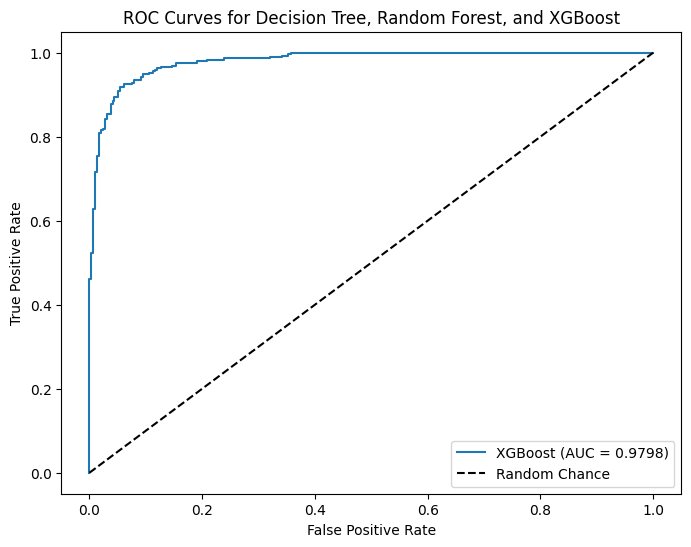

In [83]:
# Plot ROC Curve for XGBoost
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Decision Tree, Random Forest, and XGBoost')
plt.legend(loc='lower right')
plt.show()

**Written Answer:** The XGBoost outperforms the Decision tree, however, Random Forest is the most superior by fine margins. However, the decision tree curve is not the regular shape.

## **Question 4: Model Explainability with SHAP**
Machine learning models can be difficult to interpret. SHAP helps us understand which features are most important in predictions.

1. **Apply SHAP to the best-tuned XGBoost model**.
2. **Generate a SHAP Summary Plot**:
   - Displays the most important features and their impact.
3. **Interpret the results**:
   - Explain the plot for the top three features?
   - Does the result make sense?

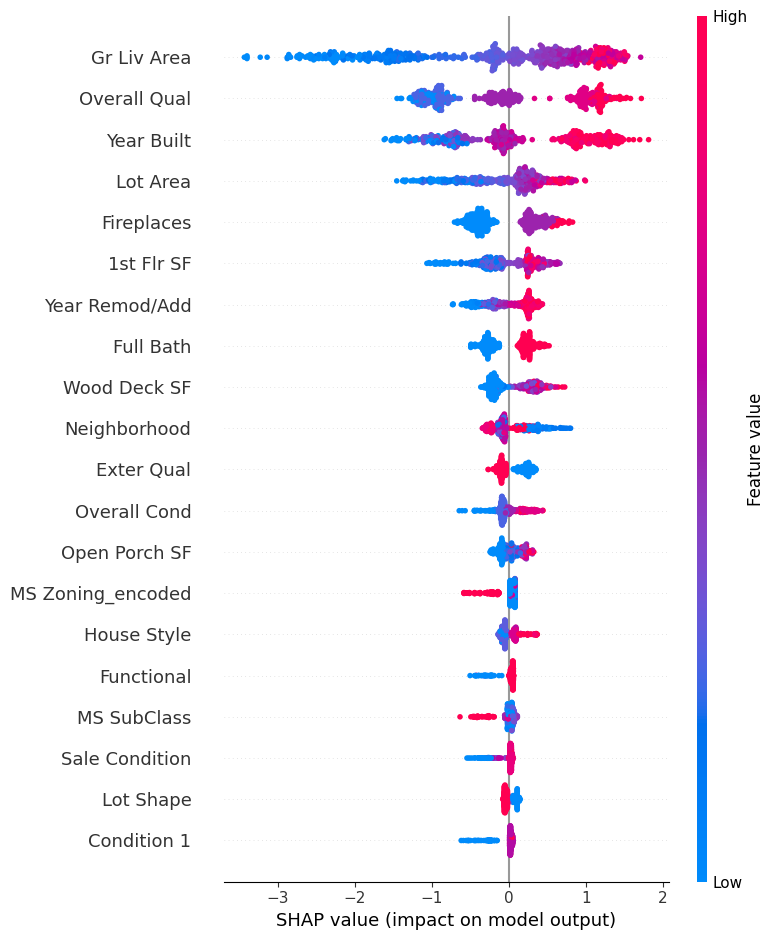

In [85]:
# Use the best-tuned XGBoost model from GridSearch
explainer = shap.TreeExplainer(best_xgb_model)


# Apply SHAP to the best XGBoost model
shap_values = explainer.shap_values(X_test_scaled)

# Generate SHAP Summary Plot
feature_names = df.drop('price_category','Unnamed: 0','Order','PID').columns
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names)


**Written Answer:** The following are the most influencial points in order:
*   The Ground Living Area: The house size has the most effect. Particularly a very small house would be cheaper, and a large house also has a positive impact
*   The material the house is built in has equal impact on the house price. The quality tends to be more influentiual to the positive price.
*   The year built also affects it. Houses tend to be more expensive if they are built later than the older houses.




